## 0. Setup

In [ ]:
INDIA_PROJECTED_CRS = "24378"

In [ ]:
# set libraries to refresh
%load_ext autoreload
%autoreload 2

In [1]:
# general
from pathlib import Path
import numpy as np
import pandas as pd
import geopandas as gpd
from tqdm.notebook import tqdm

from os import listdir

# for plotting and coloring
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import math
import matplotlib.cm

# for handling S2 cells and downloading VIDA data
import boto3
from s2cell.s2cell import lat_lon_to_cell_id
import s2sphere
from shapely.geometry import Polygon

gpd.options.io_engine = "pyogrio"

In [2]:
from gridsample.utils import create_ids, create_gmap_links, save_shapefiles

In [3]:
from utils import (
    download_VIDA_rooftops_data_by_s2,
    generate_colormap,
    get_matched_rooftop_centroids_from_s2_file,
    get_s2_cell_ids,
    s2_cell_ids_to_shapes_gdf,
)

In [4]:
ROOT_DIR = Path("../")
DATA_DIR = ROOT_DIR / "data_panel"
RAW_DATA_DIR = DATA_DIR / "01. Raw Data" # symlinked from IFS folder
CLEANED_DATA_DIR = DATA_DIR / "02. Intermediate Outputs"
OUTPUT_DATA_DIR = DATA_DIR / "03. Final Outputs" / "phase_2_training"
OUTPUT_DATA_DIR.mkdir(parents=True, exist_ok=True)

## 1. Load Pilot Boundaries

In [5]:
# get all filepaths that end in `kml` inside the folder
boundaries_dir = RAW_DATA_DIR / "99. Side Quest Data" / "Panel"/"Phase 2 Training"
all_files = list(boundaries_dir.glob("**/*.kml"))
all_files = [f for f in all_files if f.is_file()]

# load all shapes into one gdf
gdf_list = []
for filepath in all_files:
    temp_gdf = gpd.read_file(filepath)
    temp_gdf["State Name"] = filepath.stem
    gdf_list.append(temp_gdf)
gdf = pd.concat(gdf_list, ignore_index=True).to_crs(4326)

In [6]:
# change polygons to 2d polygons
# gdf = gdf.set_geometry(gdf.geometry.apply(lambda geom: geom2d(geom)))

#### Add unique ID column

In [7]:
gdf["Unique Shape ID"] = create_ids(len(gdf), "SHAPE_")
gdf

,Name,Description,geometry,State Name,Unique Shape ID
0,Alamnagar,,"POLYGON Z ((80.85245 26.84057 0.00000, 80.8568...",Uttar Pradesh,SHAPE_01
1,Para Chauki,,"POLYGON Z ((80.86057 26.83117 0.00000, 80.8680...",Uttar Pradesh,SHAPE_02
2,Buddheshwar,,"POLYGON Z ((80.83276 26.83484 0.00000, 80.8606...",Uttar Pradesh,SHAPE_03
3,Fairibipur Chauraha,,"POLYGON Z ((80.84668 26.86384 0.00000, 80.8574...",Uttar Pradesh,SHAPE_04
4,Manak Nagar,,"POLYGON Z ((80.88836 26.80869 0.00000, 80.8986...",Uttar Pradesh,SHAPE_05
5,Mohan Road Kokarimod,,"POLYGON Z ((80.86498 26.84384 0.00000, 80.8652...",Uttar Pradesh,SHAPE_06
6,Nashirabad Main Market Area,,"POLYGON Z ((74.65339 26.41546 0.00000, 74.6614...",Rajasthan,SHAPE_07
7,Somalpur,,"POLYGON Z ((74.62564 26.42126 0.00000, 74.6157...",Rajasthan,SHAPE_08
8,Ajay Nagar,,"POLYGON Z ((74.62607 26.44071 0.00000, 74.6213...",Rajasthan,SHAPE_09
9,Dhola Bhata,,"POLYGON Z ((74.63886 26.43594 0.00000, 74.6363...",Rajasthan,SHAPE_10


## 5. Download rooftops

#### Identify S2 cell IDs

In [8]:
s2_cell_ids = get_s2_cell_ids(gdf)
len(s2_cell_ids)

Shapes with spillover after round 1: 0


/Users/amiremami/IDinsight Repos/rooftop_sampling/Panel/utils.py:126: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  points = gdf.geometry.centroid.to_frame(name="geometry")


5

#### Check if identified cells cover all areas of interest

In [9]:
s2_cells_gdf = s2_cell_ids_to_shapes_gdf(s2_cell_ids)

In [10]:
# Does the S2 cell cover the entire area of the boundaries?
uncovered_area = gdf.unary_union.difference(s2_cells_gdf.unary_union).area
print(f"{uncovered_area} square degrees area not covered by an S2 cell")

0.0 square degrees area not covered by an S2 cell


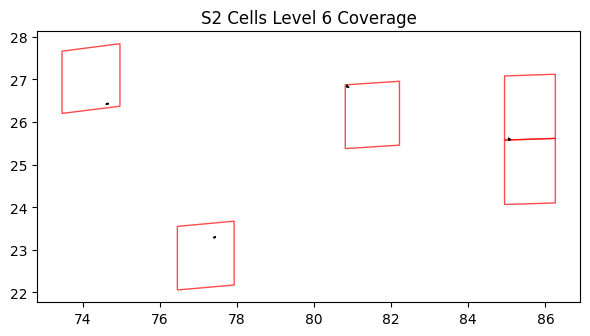

In [11]:
# Plot the S2 cells and the boundary
fig, ax = plt.subplots(1, 1, figsize=(6, 6))
gdf.boundary.plot(ax=ax, color="black", linewidth=1)
s2_cells_gdf.plot(ax=ax, facecolor="none", edgecolor="red", alpha=0.7)
plt.title("S2 Cells Level 6 Coverage")
plt.tight_layout()
plt.show()

#### Download the S2 cells

In [12]:
# download_VIDA_rooftops_data_by_s2(s2_cell_ids, "IND", RAW_DATA_DIR / "02. Rooftop Data")

## 6. Load rooftops and match to areas

In [13]:
MATCHED_ROOFTOPS_FOLDERPATH = CLEANED_DATA_DIR / "01. Matched Rooftop Data" / "Panel Phase 2 Training"

In [14]:
# # Get matched rooftops for each S2 cell
# matched_rooftop_centroids_gdf_list = []
# for s2_cell_id in tqdm(s2_cell_ids):
#     matched_rooftop_centroids_gdf = get_matched_rooftop_centroids_from_s2_file(
#         s2_file_dir=RAW_DATA_DIR / "02. Rooftop Data",
#         s2_cell_id=s2_cell_id,
#         boundaries_gdf=gdf,
#     )
#     matched_rooftop_centroids_gdf_list.append(matched_rooftop_centroids_gdf)
# matched_rooftop_centroids_gdf = pd.concat(
#     matched_rooftop_centroids_gdf_list, ignore_index=True
# )

# # Save the matched rooftops data
# save_shapefiles(
#     matched_rooftop_centroids_gdf,
#     MATCHED_ROOFTOPS_FOLDERPATH,
#     "matched_rooftops",
#     ["parquet"],
# )

In [15]:
# ax = matched_rooftop_centroids_gdf.sample(1000).plot(
#     cmap=ListedColormap(generate_colormap(len(matched_rooftop_centroids_gdf))),
# )
# gdf.plot(ax=ax, color="none", edgecolor="black", linewidth=0.5)

## 7. Load matched rooftops

In [16]:
matched_rooftops_gdf = gpd.read_parquet(MATCHED_ROOFTOPS_FOLDERPATH / "matched_rooftops.parquet")

In [17]:
len(matched_rooftops_gdf)

86424

In [19]:
no_rooftop_PSU_IDs = set(gdf["Unique Shape ID"].unique()).difference(
    set(matched_rooftops_gdf["Unique Shape ID"].unique())
)
no_rooftop_PSU_gdf = gdf[gdf["Unique Shape ID"].isin(no_rooftop_PSU_IDs)]
no_rooftop_PSU_gdf

,Name,Description,geometry,State Name,Unique Shape ID


In [20]:
# save_shapefiles(
#     no_rooftop_PSU_gdf,
#     OUTPUT_DATA_DIR / "Sampled PSUs",
#     "PSUs_with_no_rooftops",
#     ["csv", "kml"],
# )

## 8. Sample rooftops

### Do the sampling

In [70]:
# Define the base number of rooftops per shape
ROOFTOPS_PER_SHAPE = 75

sampled_rooftops = matched_rooftops_gdf.groupby(
    "Unique Shape ID", group_keys=False
).apply(
    lambda x: x.sample(
        n=ROOFTOPS_PER_SHAPE,
        random_state=42
    )
)

In [71]:
# check if we have the right number of rooftops overall
len(gdf) == (len(sampled_rooftops) / ROOFTOPS_PER_SHAPE)

True

<Axes: >

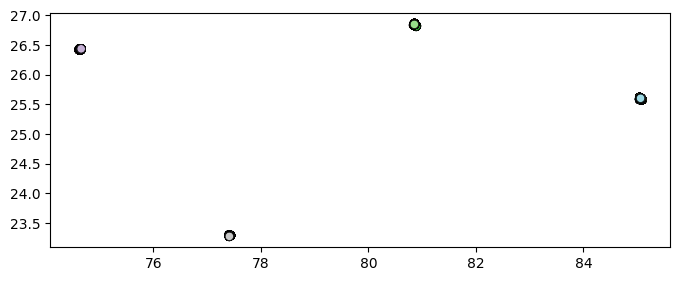

In [72]:
sampled_rooftops.plot(
    figsize=(8, 8),
    cmap="tab20",
    edgecolor="black",
    linewidth=0.5,
    legend=True,
)

### Add sample-level rooftop numbering ID columns

In [73]:
# Rooftop number within each shape
sampled_rooftops["Rooftop ID Per Shape"] = (
    sampled_rooftops.groupby("Unique Shape ID").cumcount() + 1
)

sampled_rooftops["Rooftop ID Per State"] = (
    sampled_rooftops.groupby("State Name").cumcount() + 1
)

sampled_rooftops["Unique Rooftop ID"] = sampled_rooftops.apply(
    lambda row: f"{row['State Name'].replace(' ', '_')}_{row['Unique Shape ID']}_ROOFTOP_{row['Rooftop ID Per Shape']}",
    axis=1,
)

In [74]:
sampled_rooftops

,boundary_id,bf_source,confidence,area_in_meters,s2_id,country_iso,geometry,geohash,bbox,Name,Description,State Name,Unique Shape ID,s2_rooftop_id,Rooftop ID Per Shape,Rooftop ID Per State,Unique Rooftop ID
6625,56,google,0.6776,156.1667,4150911481552044032,IND,POINT (80.85949 26.83913),tuc88jbj,"{'xmax': 80.85957500747661, 'xmin': 80.8593948...",Alamnagar,,Uttar Pradesh,SHAPE_01,S2_4150911481552044032_ROOFTOP_06626,1,1,Uttar_Pradesh_SHAPE_01_ROOFTOP_1
5068,56,google,0.6596,57.1020,4150911481552044032,IND,POINT (80.85576 26.83763),tuc2xvtk,"{'xmax': 80.85581566586292, 'xmin': 80.8557079...",Alamnagar,,Uttar Pradesh,SHAPE_01,S2_4150911481552044032_ROOFTOP_05069,2,2,Uttar_Pradesh_SHAPE_01_ROOFTOP_2
5089,56,google,0.8170,61.7516,4150911481552044032,IND,POINT (80.85619 26.83773),tuc2xvtt,"{'xmax': 80.8562464441577, 'xmin': 80.85612608...",Alamnagar,,Uttar Pradesh,SHAPE_01,S2_4150911481552044032_ROOFTOP_05090,3,3,Uttar_Pradesh_SHAPE_01_ROOFTOP_3
5049,56,google,0.8360,115.9862,4150911481552044032,IND,POINT (80.85618 26.83697),tuc2xvt8,"{'xmax': 80.8562516238197, 'xmin': 80.85610275...",Alamnagar,,Uttar Pradesh,SHAPE_01,S2_4150911481552044032_ROOFTOP_05050,4,4,Uttar_Pradesh_SHAPE_01_ROOFTOP_4
8339,56,google,0.8485,45.8488,4150911481552044032,IND,POINT (80.86383 26.84153),tuc88n75,"{'xmax': 80.8638787299657, 'xmin': 80.86378019...",Alamnagar,,Uttar Pradesh,SHAPE_01,S2_4150911481552044032_ROOFTOP_08340,5,5,Uttar_Pradesh_SHAPE_01_ROOFTOP_5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
81366,56,google,0.9087,371.7316,4173992429642317824,IND,POINT (85.06835 25.59918),tus3xu0y,"{'xmax': 85.0684414590384, 'xmin': 85.06826179...",Jalalpur,,Bihar,SHAPE_22,S2_4173992429642317824_ROOFTOP_12793,71,371,Bihar_SHAPE_22_ROOFTOP_71
77206,56,google,0.8262,94.0782,4173992429642317824,IND,POINT (85.06497 25.59510),tus3xeqq,"{'xmax': 85.065026524569, 'xmin': 85.064905306...",Jalalpur,,Bihar,SHAPE_22,S2_4173992429642317824_ROOFTOP_08633,72,372,Bihar_SHAPE_22_ROOFTOP_72
84876,56,google,0.8063,204.1072,4173992429642317824,IND,POINT (85.07905 25.60500),tus98j0x,"{'xmax': 85.0791332729434, 'xmin': 85.07896167...",Jalalpur,,Bihar,SHAPE_22,S2_4173992429642317824_ROOFTOP_16303,73,373,Bihar_SHAPE_22_ROOFTOP_73
81295,56,google,0.8648,136.3926,4173992429642317824,IND,POINT (85.06695 25.60733),tus3xtxv,"{'xmax': 85.0670102392298, 'xmin': 85.06688440...",Jalalpur,,Bihar,SHAPE_22,S2_4173992429642317824_ROOFTOP_12722,74,374,Bihar_SHAPE_22_ROOFTOP_74


### Add gmap link

In [75]:
sampled_rooftops["latitude_original"] = sampled_rooftops.geometry.y
sampled_rooftops["longitude_original"] = sampled_rooftops.geometry.x
sampled_rooftops["gmap_link_original"] = create_gmap_links(
    df=sampled_rooftops,
    lat_name="latitude_original",
    lon_name="longitude_original",
)

### Select only useful columns

In [76]:
sampled_rooftops.columns

Index(['boundary_id', 'bf_source', 'confidence', 'area_in_meters', 's2_id',
       'country_iso', 'geometry', 'geohash', 'bbox', 'Name', 'Description',
       'State Name', 'Unique Shape ID', 's2_rooftop_id',
       'Rooftop ID Per Shape', 'Rooftop ID Per State', 'Unique Rooftop ID',
       'latitude_original', 'longitude_original', 'gmap_link_original'],
      dtype='object')

In [77]:
chosen_cols = [
    "Unique Rooftop ID",
    "Unique Shape ID",
    "State Name",
    "Rooftop ID Per Shape",
    "latitude_original",
    "longitude_original",
    "gmap_link_original",
    "geometry",
    # ## rooftop info
    # "boundary_id",
    # "bf_source",
    # "confidence",
    # "area_in_meters",
    # "s2_id",
    # "country_iso",
    # "geohash",
    # "bbox",
]

In [78]:
sampled_rooftops_organised_gdf = sampled_rooftops[chosen_cols]

In [79]:
sampled_rooftops_organised_gdf

,Unique Rooftop ID,Unique Shape ID,State Name,Rooftop ID Per Shape,latitude_original,longitude_original,gmap_link_original,geometry
6625,Uttar_Pradesh_SHAPE_01_ROOFTOP_1,SHAPE_01,Uttar Pradesh,1,26.839126,80.859486,https://www.google.com/maps/search/?api=1&quer...,POINT (80.85949 26.83913)
5068,Uttar_Pradesh_SHAPE_01_ROOFTOP_2,SHAPE_01,Uttar Pradesh,2,26.837634,80.855762,https://www.google.com/maps/search/?api=1&quer...,POINT (80.85576 26.83763)
5089,Uttar_Pradesh_SHAPE_01_ROOFTOP_3,SHAPE_01,Uttar Pradesh,3,26.837731,80.856186,https://www.google.com/maps/search/?api=1&quer...,POINT (80.85619 26.83773)
5049,Uttar_Pradesh_SHAPE_01_ROOFTOP_4,SHAPE_01,Uttar Pradesh,4,26.836969,80.856177,https://www.google.com/maps/search/?api=1&quer...,POINT (80.85618 26.83697)
8339,Uttar_Pradesh_SHAPE_01_ROOFTOP_5,SHAPE_01,Uttar Pradesh,5,26.841527,80.863829,https://www.google.com/maps/search/?api=1&quer...,POINT (80.86383 26.84153)
...,...,...,...,...,...,...,...,...
81366,Bihar_SHAPE_22_ROOFTOP_71,SHAPE_22,Bihar,71,25.599179,85.068354,https://www.google.com/maps/search/?api=1&quer...,POINT (85.06835 25.59918)
77206,Bihar_SHAPE_22_ROOFTOP_72,SHAPE_22,Bihar,72,25.595102,85.064966,https://www.google.com/maps/search/?api=1&quer...,POINT (85.06497 25.59510)
84876,Bihar_SHAPE_22_ROOFTOP_73,SHAPE_22,Bihar,73,25.605000,85.079047,https://www.google.com/maps/search/?api=1&quer...,POINT (85.07905 25.60500)
81295,Bihar_SHAPE_22_ROOFTOP_74,SHAPE_22,Bihar,74,25.607331,85.066947,https://www.google.com/maps/search/?api=1&quer...,POINT (85.06695 25.60733)


### Save sampled data (original rooftop pins)

In [80]:
save_shapefiles(
    sampled_rooftops_organised_gdf,
    OUTPUT_DATA_DIR / "01. Sampled Rooftop Data",
    "sampled_rooftops_centroids_original",
    ["csv", "parquet", "kml"],
)

/Users/amiremami/.pyenv/versions/geospatial/lib/python3.12/site-packages/pyogrio/raw.py:723: RuntimeWarning: Field sampled_rooftops_centroids_original.Rooftop ID Per Shape: Lossy conversion occurred when trying to set 64 bit integer field from real value 80.8594857721788.
  ogr_write(
/Users/amiremami/.pyenv/versions/geospatial/lib/python3.12/site-packages/pyogrio/raw.py:723: RuntimeWarning: Value 'https://www.google.com/maps/search/?api=1&query=26.839125574801393,80.8594857721788' of field sampled_rooftops_centroids_original.latitude_original parsed incompletely to real 0.
  ogr_write(
/Users/amiremami/.pyenv/versions/geospatial/lib/python3.12/site-packages/pyogrio/raw.py:723: RuntimeWarning: Field sampled_rooftops_centroids_original.Rooftop ID Per Shape: Lossy conversion occurred when trying to set 64 bit integer field from real value 80.855761799412875.
  ogr_write(
/Users/amiremami/.pyenv/versions/geospatial/lib/python3.12/site-packages/pyogrio/raw.py:723: RuntimeWarning: Value 'ht

## 9. Snap points to road

In [81]:
import yaml
from shapely import Point

from utils import get_nearest_points_on_road_batch, get_nearest_points_on_road_batch_parallel

In [82]:
# load API key
with open("../secrets/api_keys.yaml", "r") as f:
    config = yaml.safe_load(f)
    api_key = config["GOOGLE_ROADS_API_KEY"]

In [83]:
get_nearest_points_on_road_batch([Point(77.11432151622034, 28.677391409999522)], api_key)

[<POINT (77.114 28.677)>]

In [84]:
# test
get_nearest_points_on_road_batch(sampled_rooftops_organised_gdf.geometry.iloc[:5], api_key)

[<POINT (80.86 26.839)>,
 <POINT (80.856 26.838)>,
 <POINT (80.856 26.838)>,
 <POINT (80.856 26.837)>,
 <POINT (80.864 26.842)>]

In [85]:
get_nearest_points_on_road_batch_parallel(sampled_rooftops_organised_gdf.iloc[:150], api_key)

Snapping points to roads (batched):   0%|          | 0/2 [00:00<?, ?it/s]

6625     POINT (80.85954 26.83909)
5068     POINT (80.85577 26.83763)
5089     POINT (80.85617 26.83774)
5049     POINT (80.85611 26.83701)
8339     POINT (80.86395 26.84164)
                   ...            
15432    POINT (80.86940 26.82680)
20255    POINT (80.87693 26.83494)
19521    POINT (80.87220 26.83491)
20069    POINT (80.87490 26.83572)
16283    POINT (80.86956 26.82960)
Length: 150, dtype: geometry

#### Snap points to road

In [86]:
snapped_points_series = get_nearest_points_on_road_batch_parallel(
    sampled_rooftops_organised_gdf, api_key, max_workers=12
)
# took 1 second for 1,600 points (Panel)
# 30s for all 53,000 points 

Snapping points to roads (batched):   0%|          | 0/17 [00:00<?, ?it/s]

In [87]:
sampled_rooftops_snapped_gdf = sampled_rooftops_organised_gdf.copy()
sampled_rooftops_snapped_gdf["geometry_snapped"] = sampled_rooftops_snapped_gdf.index.map(snapped_points_series)

In [88]:
# Make new Geometry Type column which has values "Original" or "Snapped to Road"
sampled_rooftops_snapped_gdf["Geometry Type"] = (
    sampled_rooftops_snapped_gdf["geometry_snapped"]
    .notna()
    .replace({True: "Snapped to Road", False: "Original"})
)
sampled_rooftops_snapped_gdf["Geometry Type"].value_counts()

Geometry Type
Snapped to Road    1649
Original              1
Name: count, dtype: int64

#### Replace geometry to snapped one (missing filled in with original)

In [89]:
# backup the original geometry
sampled_rooftops_snapped_gdf["geometry_original"] = sampled_rooftops_snapped_gdf[
    "geometry"
]
# replace the original geometry with the snapped geometry
sampled_rooftops_snapped_gdf["geometry"] = sampled_rooftops_snapped_gdf[
    "geometry_snapped"
]
# drop the snapped geometry column
sampled_rooftops_snapped_gdf = sampled_rooftops_snapped_gdf.drop(
    columns=["geometry_snapped"]
)
# fill in NaN values in the snapped geometry with the original geometry
sampled_rooftops_snapped_gdf["geometry"] = sampled_rooftops_snapped_gdf[
    "geometry"
].fillna(sampled_rooftops_snapped_gdf["geometry_original"])

In [90]:
sampled_rooftops_snapped_gdf["geometry"].isna().sum()

0

#### Update lat, lon, gmap_link

In [91]:
sampled_rooftops_snapped_gdf["latitude"] = list(sampled_rooftops_snapped_gdf.geometry.y)
sampled_rooftops_snapped_gdf["longitude"] = list(
    sampled_rooftops_snapped_gdf.geometry.x
)
sampled_rooftops_snapped_gdf["gmap_link"] = create_gmap_links(
    df=sampled_rooftops_snapped_gdf,
    lat_name="latitude",
    lon_name="longitude",
)

#### Reorganise

In [93]:
sampled_rooftops_snapped_gdf = sampled_rooftops_snapped_gdf[
    [
        # IDs
        "Unique Rooftop ID",
        "Unique Shape ID",
        "State Name",
        "Rooftop ID Per Shape",
        "Geometry Type",
        # new points
        "geometry",
        "latitude",
        "longitude",
        "gmap_link",
        # original points
        "latitude_original",
        "longitude_original",
        "gmap_link_original",
        "geometry_original",
    ]
]

#### Make lines between original and snapped points

In [95]:
from shapely.geometry import LineString

In [96]:
sampled_rooftops_snapped_gdf["geometry_line"] = sampled_rooftops_snapped_gdf.apply(
    lambda row: LineString([row["geometry_original"], row["geometry"]]), axis=1
)

In [97]:
sampled_rooftops_snapped_gdf["geometry_line"].isna().sum()

0

#### Save new files: snapped points, snapped lines

In [98]:
# Save CSV and parquet
save_shapefiles(
    sampled_rooftops_snapped_gdf.drop(
        columns=[
            "geometry_original",
            "geometry_line",
        ]
    ),
    OUTPUT_DATA_DIR / "01. Sampled Rooftop Data",
    "sampled_rooftops_snapped_points",
    ["csv", "parquet"],
)

In [99]:
# Save KML
save_shapefiles(
    sampled_rooftops_snapped_gdf.drop(
        columns=[
            "geometry_original",
            "geometry_line",
            # bad cols for KML
            "gmap_link_original",
            "gmap_link"
        ]
    ),
    OUTPUT_DATA_DIR / "01. Sampled Rooftop Data",
    "sampled_rooftops_snapped_points",
    ["kml"],
)

/Users/amiremami/.pyenv/versions/geospatial/lib/python3.12/site-packages/pyogrio/raw.py:723: RuntimeWarning: Field sampled_rooftops_snapped_points.Rooftop ID Per Shape: Lossy conversion occurred when trying to set 64 bit integer field from real value 26.839091649257366.
  ogr_write(
/Users/amiremami/.pyenv/versions/geospatial/lib/python3.12/site-packages/pyogrio/raw.py:723: RuntimeWarning: Field sampled_rooftops_snapped_points.Rooftop ID Per Shape: Lossy conversion occurred when trying to set 64 bit integer field from real value 26.837629021741677.
  ogr_write(
/Users/amiremami/.pyenv/versions/geospatial/lib/python3.12/site-packages/pyogrio/raw.py:723: RuntimeWarning: Field sampled_rooftops_snapped_points.Rooftop ID Per Shape: Lossy conversion occurred when trying to set 64 bit integer field from real value 26.837737387669367.
  ogr_write(
/Users/amiremami/.pyenv/versions/geospatial/lib/python3.12/site-packages/pyogrio/raw.py:723: RuntimeWarning: Field sampled_rooftops_snapped_points.R

In [100]:
# Save lines
sampled_rooftops_line_gdf = sampled_rooftops_snapped_gdf.copy()
sampled_rooftops_line_gdf["geometry"] = sampled_rooftops_line_gdf["geometry_line"]
sampled_rooftops_line_gdf = sampled_rooftops_line_gdf.drop(
    columns=["geometry_original", "geometry_line"]
)

In [101]:
save_shapefiles(
    sampled_rooftops_line_gdf.drop(
        # drop kml unfriendly columns
        columns=["gmap_link_original", "gmap_link"]
    ),
    OUTPUT_DATA_DIR / "01. Sampled Rooftop Data",
    "sampled_rooftops_snapped_lines",
    ["parquet", "kml"],
)

/Users/amiremami/.pyenv/versions/geospatial/lib/python3.12/site-packages/pyogrio/raw.py:723: RuntimeWarning: Field sampled_rooftops_snapped_lines.Rooftop ID Per Shape: Lossy conversion occurred when trying to set 64 bit integer field from real value 26.839091649257366.
  ogr_write(
/Users/amiremami/.pyenv/versions/geospatial/lib/python3.12/site-packages/pyogrio/raw.py:723: RuntimeWarning: Field sampled_rooftops_snapped_lines.Rooftop ID Per Shape: Lossy conversion occurred when trying to set 64 bit integer field from real value 26.837629021741677.
  ogr_write(
/Users/amiremami/.pyenv/versions/geospatial/lib/python3.12/site-packages/pyogrio/raw.py:723: RuntimeWarning: Field sampled_rooftops_snapped_lines.Rooftop ID Per Shape: Lossy conversion occurred when trying to set 64 bit integer field from real value 26.837737387669367.
  ogr_write(
/Users/amiremami/.pyenv/versions/geospatial/lib/python3.12/site-packages/pyogrio/raw.py:723: RuntimeWarning: Field sampled_rooftops_snapped_lines.Rooft

## Save per state

In [103]:
for state in tqdm(sampled_rooftops_organised_gdf["State Name"].unique()):
    state_output_folder = OUTPUT_DATA_DIR / "01. Sampled Rooftop Data" / state

    # save original points
    selected_state_original_gdf = sampled_rooftops_organised_gdf[
        sampled_rooftops_organised_gdf["State Name"] == state
    ]
    print(len(selected_state_original_gdf))

    save_shapefiles(
        selected_state_original_gdf,
        state_output_folder,
        f"{state}_sampled_rooftops_centroids_original",
        ["csv", "parquet"],
    )
    save_shapefiles(
        selected_state_original_gdf.drop(
            # drop kml unfriendly columns
            columns=["gmap_link_original"]
        ),
        state_output_folder,
        f"{state}_sampled_rooftops_centroids_original",
        ["kml"],
    )

    # Save snapped points
    selected_state_snapped_gdf = sampled_rooftops_snapped_gdf[
        sampled_rooftops_snapped_gdf["State Name"] == state
    ].drop(
        columns=[
            "geometry_original",
            "geometry_line",
        ]
    )
    save_shapefiles(
        selected_state_snapped_gdf,
        state_output_folder,
        f"{state}_sampled_rooftops_snapped_points",
        ["csv", "parquet"],
    )
    save_shapefiles(
        selected_state_snapped_gdf.drop(
            # drop kml unfriendly columns
            columns=["gmap_link_original", "gmap_link"]
        ),
        state_output_folder,
        f"{state}_sampled_rooftops_snapped_points",
        ["kml"],
    )

    # Save lines
    selected_state_sampled_rooftops_line_gdf = sampled_rooftops_line_gdf[
        sampled_rooftops_line_gdf["State Name"] == state
    ]
    save_shapefiles(
        selected_state_sampled_rooftops_line_gdf.drop(
            # drop kml unfriendly columns
            columns=["gmap_link_original", "gmap_link"]
        ),
        state_output_folder,
        f"{state}_sampled_rooftops_snapped_lines",
        ["parquet", "kml"],
    )

  0%|          | 0/4 [00:00<?, ?it/s]

450
375
450
375


/Users/amiremami/.pyenv/versions/geospatial/lib/python3.12/site-packages/pyogrio/raw.py:723: RuntimeWarning: Layer name 'Uttar Pradesh_sampled_rooftops_centroids_original' adjusted to 'Uttar_Pradesh_sampled_rooftops_centroids_original' for XML validity.
  ogr_write(
/Users/amiremami/.pyenv/versions/geospatial/lib/python3.12/site-packages/pyogrio/raw.py:723: RuntimeWarning: Field Uttar_Pradesh_sampled_rooftops_centroids_original.Rooftop ID Per Shape: Lossy conversion occurred when trying to set 64 bit integer field from real value 80.8594857721788.
  ogr_write(
/Users/amiremami/.pyenv/versions/geospatial/lib/python3.12/site-packages/pyogrio/raw.py:723: RuntimeWarning: Field Uttar_Pradesh_sampled_rooftops_centroids_original.Rooftop ID Per Shape: Lossy conversion occurred when trying to set 64 bit integer field from real value 80.855761799412875.
  ogr_write(
/Users/amiremami/.pyenv/versions/geospatial/lib/python3.12/site-packages/pyogrio/raw.py:723: RuntimeWarning: Field Uttar_Pradesh_sa